# โครงสร้างอายุครูไทย: วิเคราะห์ระดับประเทศและระดับจังหวัด

วิเคราะห์โครงสร้างอายุของข้าราชการครูและบุคลากรทางการศึกษาสังกัด สพฐ. ด้วย Pandas, Seaborn และ GeoPandas ครอบคลุมทั้งภาพรวมระดับประเทศและการกระจายตัวเชิงพื้นที่รายจังหวัด

**แหล่งข้อมูล**
* [จำนวนข้าราชการครูและบุคลากรทางการศึกษา](https://opendata.obec.go.th/en/dataset/16) — OBEC Open Data
  
* File: `teacher_by_age.json` <br>
  [จำนวนข้าราชการครูฯ จำแนกตามส่วนราชการและช่วงอายุ](https://hrms.obec.go.th/api/opendata/dataset_personal/13)  <br>
  (ดึงข้อมูลเมื่อวันที่ 4 ส.ค. 2569; URL: https://hrms.obec.go.th/api/opendata/dataset_personal/13)
* File: `provinces.geojson` <br>
  [ขอบเขตจังหวัดประเทศไทย (GeoJSON)](https://github.com/chingchai/OpenGISData-Thailand) — OpenGISData-Thailand <br>
  (ดึงข้อมูลเมื่อวันที่ 4 ส.ค. 2569; URL: 'https://raw.githubusercontent.com/chingchai/OpenGISData-Thailand/master/provinces.geojson')

**ขอบเขตข้อมูล**: กราฟภาพรวมระดับประเทศใช้ข้อมูลทุกสังกัด ส่วนแผนที่รายจังหวัดครอบคลุมเฉพาะสังกัดที่ระบุจังหวัดได้แม่นยำ (รายละเอียดในหัวข้อวิเคราะห์เชิงพื้นที่)


**เตรียมข้อมูล** — โหลด JSON เป็น DataFrame, สกัดชื่อจังหวัดเบื้องต้น, ตั้งชื่อคอลัมน์ช่วงอายุใหม่ให้อ่านง่าย

In [2]:
import pandas as pd

tage = pd.read_json('teacher_by_age.json')
tage['province'] = tage['Government'].apply(lambda s: s.split('เขต')[0].split('.')[-1])
tage.set_index('Num', inplace=True)

teacher_by_age = (
    tage.drop(['Error_data','Old_average'], axis=1)
        .rename(columns={
        'Less_21':'< 21 ปี',
        'Inter_21_25': '21-25 ปี',
        'Inter_26_30': '26-30 ปี',
        'Inter_31_35': '31-35 ปี',
        'Inter_36_40': '36-40 ปี',
        'Inter_41_45': '41-45 ปี',
        'Inter_46_50': '46-50 ปี',
        'Inter_51_60': '51-60 ปี',
        'More_60': '> 60 ปี',
    })
)

**ยอดรวมต่อเขตพื้นที่** — เก็บผลรวม (`Sum`) ต่อเขตไว้ใช้ตรวจสอบความถูกต้องในขั้นถัดไป

In [3]:
sumt = teacher_by_age.loc[:, ['Government','Sum']].dropna()
sumt = sumt.loc[sumt['Government']!= 'percent']
sumt.sort_values(by='Government')

,Government,Sum
Num,,
221,สพป.กระบี่,4548.0
64,สพป.กรุงเทพมหานคร,2948.0
202,สพป.กาญจนบุรี เขต 1,3219.0
203,สพป.กาญจนบุรี เขต 2,2280.0
204,สพป.กาญจนบุรี เขต 3,2632.0
...,...,...
60,สพม.เพชรบูรณ์,3114.0
33,สพม.เลย หนองบัวลำภู,4413.0
56,สพม.แพร่,1723.0


**ตรวจสอบความถูกต้องของข้อมูล (Data Integrity Check)** — ยืนยันว่าผลรวมแต่ละแถวที่คำนวณเองตรงกับคอลัมน์ `Sum` ที่ต้นทางให้มา ก่อนนำไปวิเคราะห์ต่อ

In [4]:
teacher_by_age.drop('Sum', axis=1, inplace=True)

# เรียงลำดับคอลัมน์ใหม่
teacher_by_age =   teacher_by_age[['Government', 'province', '< 21 ปี', '21-25 ปี', '26-30 ปี', '31-35 ปี', '36-40 ปี', 
                            '41-45 ปี', '46-50 ปี', '51-60 ปี', '> 60 ปี']].dropna()
# ตรวจเช็คผลรวม
assert (
    teacher_by_age.sort_values(by='Government')
    .drop(['Government','province'],axis=1)
    .sum(axis=1).to_numpy() == sumt.sort_values(by='Government')['Sum'].to_numpy()
).sum() == teacher_by_age.shape[0]

**สรุปเบื้องต้น** — จำนวนครูแยกตามช่วงอายุ และยอดรวมทั้งระบบ

In [15]:
teacher_by_age.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 1 to 246
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Government  246 non-null    str    
 1   province    246 non-null    str    
 2   < 21 ปี     246 non-null    float64
 3   21-25 ปี    246 non-null    float64
 4   26-30 ปี    246 non-null    float64
 5   31-35 ปี    246 non-null    float64
 6   36-40 ปี    246 non-null    float64
 7   41-45 ปี    246 non-null    float64
 8   46-50 ปี    246 non-null    float64
 9   51-60 ปี    246 non-null    float64
 10  > 60 ปี     246 non-null    float64
dtypes: float64(9), str(2)
memory usage: 21.3 KB


In [17]:
# distribution by age group
teacher_by_age.iloc[:, 2:].sum(axis=0)

< 21 ปี          0.0
21-25 ปี     23807.0
26-30 ปี    138794.0
31-35 ปี    173039.0
36-40 ปี    123589.0
41-45 ปี    114664.0
46-50 ปี     94870.0
51-60 ปี    162235.0
> 60 ปี       7535.0
dtype: float64

In [7]:
# จำนวนบุคลากรทั้งหมด
num_all_teachers = int(teacher_by_age.iloc[:, 2:].sum(axis=0).sum())
print(f"จำนวนบุคลากรทั้งประเทศ = {num_all_teachers:,d} คน")

จำนวนบุคลากรทั้งประเทศ = 838,533 คน


<hr>

## ภาพรวมระดับประเทศ: การกระจายตัวตามช่วงอายุ (ทุกสังกัด)

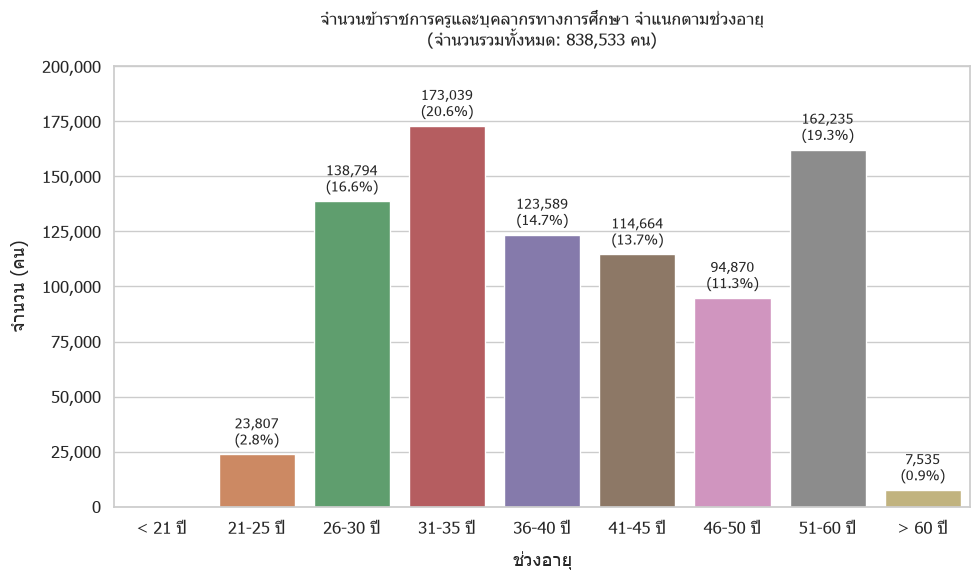

In [8]:
import math

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

def comma_fmt(x, pos):
    return f'{int(x):,}'

def round_to_highest_place(val):
    if val == 0:
        return 0
    
    # Calculate the exponent for base 10
    num_zeros = math.floor(math.log10(abs(val)))
    
    # Round using the negative calculated exponent
    return round(val, -num_zeros)


# ตั้งค่า Theme
sns.set_theme(style='whitegrid', palette='deep', font='Tahoma', font_scale=1.1)

# คำนวณข้อมูล
df = teacher_by_age.iloc[:, 2:].sum(axis=0)
total_teachers = df.sum()  # จำนวนครูรวมทั้งหมด

# พล็อตกราฟแท่งจำแนกตามอายุ
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=df.index, y=df, ax=ax, hue=df.index, legend=False)

# --- วนลูปใส่ Data Labels (จำนวน + %) ---
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total_teachers) * 100
        # รูปแบบข้อความ: 173,200\n(37.2%)  (\n คือการขึ้นบรรทัดใหม่)
        label_text = f'{int(height):,}\n({percentage:.1f}%)'
        
        ax.annotate(
            label_text,
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=10,
            linespacing=1.2  # ระยะห่างระหว่างบรรทัดข้อความ
        )

# กำหนดชื่อแกนและ Title
ax.set_xlabel('ช่วงอายุ', labelpad=10)
ax.set_ylabel('จำนวน (คน)', labelpad=10)

# แสดงจำนวนรวมไว้ในชื่อเรื่อง (Title) หรือ Subtitle
ax.set_title(
    f'จำนวนข้าราชการครูและบุคลากรทางการศึกษา จำแนกตามช่วงอายุ\n(จำนวนรวมทั้งหมด: {total_teachers:,.0f} คน)', 
    pad=15, 
    fontsize=12
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(comma_fmt))

# เพิ่มพื้นที่ด้านบนแกน Y เพื่อไม่ให้ตัวเลขและ % ทับขอบกราฟ
ax.set_ylim(0, round_to_highest_place(df.max() * 1.18))

plt.tight_layout()
plt.savefig('teacher_by_age.png', dpi=300)
plt.show()

**จัดกลุ่มใหม่เป็นช่วงทศวรรษ** — รวมช่วงอายุ 5 ปีเป็น 10 ปี เพื่อดูแนวโน้มภาพใหญ่ให้ชัดขึ้น

In [9]:
tf = teacher_by_age[['province']]
tf['< 21 ปี']  = teacher_by_age['< 21 ปี']
tf['21-30 ปี'] = teacher_by_age['21-25 ปี'] + teacher_by_age['26-30 ปี']
tf['31-40 ปี'] = teacher_by_age['31-35 ปี'] + teacher_by_age['36-40 ปี']
tf['41-50 ปี'] = teacher_by_age['41-45 ปี'] + teacher_by_age['46-50 ปี']
tf['51-60 ปี'] = teacher_by_age['51-60 ปี'] 
tf['> 60 ปี']  = teacher_by_age['> 60 ปี']

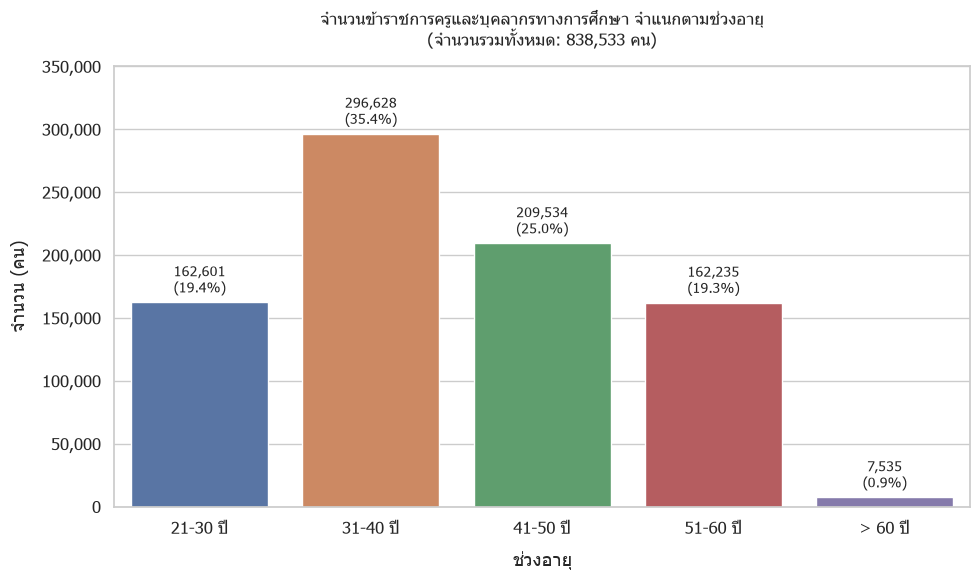

In [10]:
def round_to_desired_place(val, place):
    if val == 0:
        return 0
    
    # Calculate the exponent for base 10
    num_zeros = math.floor(math.log10(abs(val))) - (place-1)
    
    # Round using the negative calculated exponent
    return round(val, -num_zeros)


# คำนวณข้อมูล
df = tf.iloc[:, 2:].sum(axis=0)
total_teachers = df.sum()  # จำนวนครูรวมทั้งหมด

# พล็อตกราฟแท่งตามช่วงอายุ
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=df.index, y=df, ax=ax, hue=df.index, legend=False)

# --- วนลูปใส่ Data Labels (จำนวน + %) ---
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total_teachers) * 100
        # รูปแบบข้อความ: 173,200\n(37.2%)  (\n คือการขึ้นบรรทัดใหม่)
        label_text = f'{int(height):,}\n({percentage:.1f}%)'
        
        ax.annotate(
            label_text,
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=10,
            linespacing=1.2  # ระยะห่างระหว่างบรรทัดข้อความ
        )

# กำหนดชื่อแกนและ Title
ax.set_xlabel('ช่วงอายุ', labelpad=10)
ax.set_ylabel('จำนวน (คน)', labelpad=10)

# แสดงจำนวนรวมไว้ในชื่อเรื่อง (Title) หรือ Subtitle
ax.set_title(
    f'จำนวนข้าราชการครูและบุคลากรทางการศึกษา จำแนกตามช่วงอายุ\n(จำนวนรวมทั้งหมด: {total_teachers:,.0f} คน)', 
    pad=15, 
    fontsize=12
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(comma_fmt))

# เพิ่มพื้นที่ด้านบนแกน Y เพื่อไม่ให้ตัวเลขและ % ทับขอบกราฟ
ax.set_ylim(0, round_to_desired_place(df.max() * 1.18, 2))

plt.tight_layout()
plt.savefig('teacher_by_age_decade.png', dpi=300)
plt.show()

**Observation**
* **31–40 ปี คือกำลังหลัก** — 296,628 คน (35.4%) มีประสบการณ์สอนราว 5–15 ปี พร้อมทั้งทักษะและความคุ้นเคยกับเทคโนโลยี
* **อัตราทดแทนระดับประเทศดูสมดุล** — กลุ่ม 21–30 ปี (162,601 คน) ใกล้เคียงกับกลุ่ม 51–60 ปี (162,235 คน) เกือบเท่ากัน
* **41–50 ปี (25.0%)** เป็นกำลังสำรองสำหรับการเกษียณระลอกถัดไป และมีบทบาทเป็นพี่เลี้ยงครูรุ่นใหม่


<hr>

## การกระจายตัวเชิงพื้นที่ระดับจังหวัด

ตัวเลขระดับประเทศข้างต้นเป็นค่าเฉลี่ยที่อาจซ่อนความเหลื่อมล้ำเชิงพื้นที่ไว้ ส่วนนี้จึงขยับจากกราฟแท่งไปเป็นแผนที่ระดับจังหวัด เพื่อดูว่า "ความสมดุล" ที่เห็นในภาพรวม กระจายอยู่ทั่วทุกจังหวัดจริงหรือไม่


**โหลดขอบเขตจังหวัด** จาก GeoJSON สาธารณะ

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Tahoma'  # ฟอนต์ไทยเดิมที่เคยตั้งค่าไว้แล้ว

provinces_gdf = gpd.read_file("provinces.geojson")

**เตรียมข้อมูลระดับจังหวัด — ประเด็นที่ต้องระวัง**

หลังประกาศกระทรวงศึกษาธิการ 28 ม.ค. 2564 เขตพื้นที่มัธยมศึกษาเปลี่ยนจาก 42 เป็น [62 เขต](https://moe360.blog/2021/02/17/secondary-education-area/) โดย **15 เขตครอบคลุมมากกว่า 1 จังหวัดในสำนักงานเดียว** (เช่น "สพม.ชลบุรี ระยอง") ทำให้ join ชื่อเขตเข้ากับจังหวัดแบบตรงไปตรงมาไม่แม่นยำ — ค่าจะถูกรวมไว้ที่จังหวัดเดียวทั้งที่เป็นของสองจังหวัดรวมกัน

จึงตัด 15 เขตนี้ออกจากแผนที่ (เก็บเฉพาะ สพป. ทุกเขต + สพม. เขตเดี่ยว 47 เขตที่ join ได้แม่นยำ) ผลคือแผนที่ครอบคลุมครู 761,275 คน จาก 838,533 คน (คิดเป็นเปอร์เซ็นต์ความครอบคลุม 90.8%)


In [12]:
# สพป. 
sapor = teacher_by_age[teacher_by_age['Government'].str.startswith('สพป.')].copy()
sapor['province_clean'] = (
    sapor['Government'].str.replace(r'สพป\.', '', regex=True)
    .str.replace(r'\s*เขต\s*\d+', '', regex=True).str.strip()
)

# สพม. — ตัดเขตคร่อมจังหวัดออก
merged_office_names = [
    'จันทบุรี ตราด', 'ชลบุรี ระยอง', 'ตรัง กระบี่', 'ปราจีนบุรี นครนายก',
    'พังงา ภูเก็ต ระนอง', 'พิษณุโลก อุตรดิตถ์', 'ลำปาง ลำพูน',
    'เลย หนองบัวลำภู', 'ศรีสะเกษ ยโสธร', 'สงขลา สตูล',
    'สมุทรสาคร สมุทรสงคราม', 'สิงห์บุรี อ่างทอง', 'สุราษฎร์ธานี ชุมพร',
    'อุทัยธานี ชัยนาท', 'อุบลราชธานี อำนาจเจริญ',
]
sapom = teacher_by_age[teacher_by_age['Government'].str.startswith('สพม.')].copy()
sapom['office_name'] = (
    sapom['Government'].str.replace('สพม.', '', regex=False)
    .str.replace(r'\s*เขต\s*\d+', '', regex=True).str.strip()
    .str.strip()
)
sapom_clean = sapom[~sapom['office_name'].isin(merged_office_names)].copy()
sapom_clean['province_clean'] = sapom_clean['office_name']  # เขตเดี่ยว ชื่อเขต = ชื่อจังหวัดอยู่แล้ว

# รวมสองกลุ่ม แล้ว groupby ตามเดิม
combined = pd.concat([sapor, sapom_clean], ignore_index=True)

age_cols = ['< 21 ปี','21-25 ปี','26-30 ปี','31-35 ปี','36-40 ปี',
            '41-45 ปี','46-50 ปี','51-60 ปี','> 60 ปี']
combined['senior'] = combined['51-60 ปี'] + combined['> 60 ปี']
combined['total']  = combined[age_cols].sum(axis=1)
province_agg = combined.groupby('province_clean')[['senior','total']].sum()
province_agg['pct_senior'] = province_agg['senior'] / province_agg['total'] * 100

print('ครอบคลุม:', province_agg['total'].sum(), f"({province_agg['total'].sum()/838533*100:.1f}%)")

ครอบคลุม: 761275.0 (90.8%)


**ตรวจสอบการจับคู่ชื่อจังหวัด** กับ GeoJSON ก่อนวาดแผนที่เสมอ

In [13]:
# 4. เช็กว่าชื่อจังหวัดตรงกับ geojson ครบไหม (อย่าข้ามขั้นตอนนี้!)
unmatched = set(province_agg.index) - set(provinces_gdf['pro_th'])
print('จับคู่ไม่ได้:', unmatched)

จับคู่ไม่ได้: set()


**วาดแผนที่** — ใช้ diverging colormap (`RdBu_r`) พร้อม `TwoSlopeNorm` กำหนดจุดกึ่งกลางที่ค่าเฉลี่ยประเทศจริง และตัดสเกลสีที่ percentile 10/90 (`extend='both'`) เพื่อไม่ให้ outlier ดึงคอนทราสต์ของทั้งแผนที่ให้จางลง


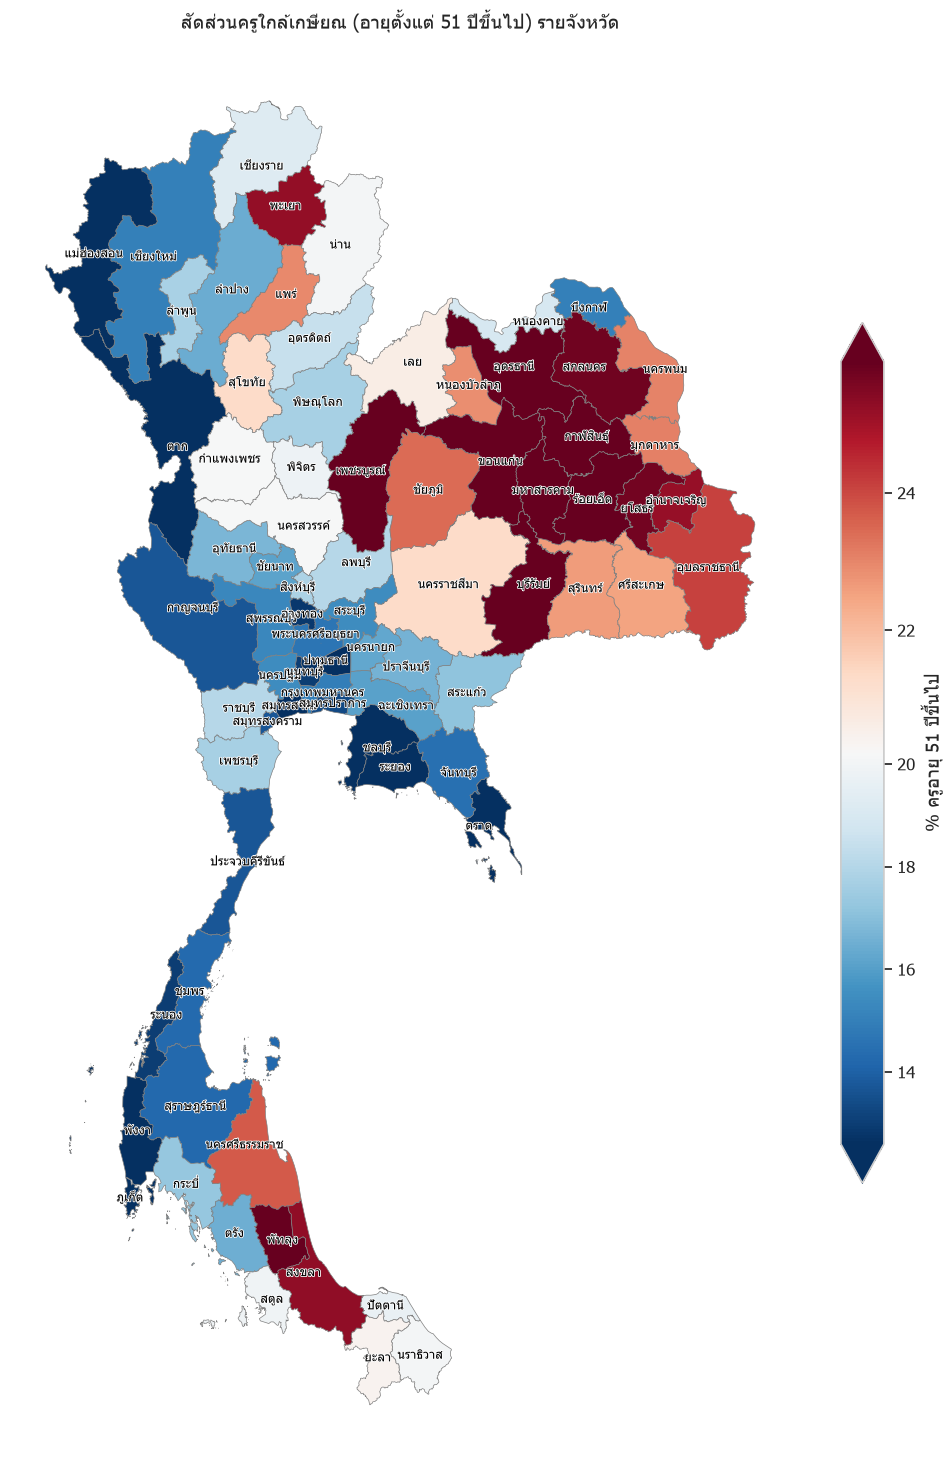

In [14]:
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm
import numpy as np

national_avg = province_agg['senior'].sum() / province_agg['total'].sum() * 100  # คำนวณจากข้อมูลจริง

# 5. รวมข้อมูล + วาดแผนที่
merged = provinces_gdf.merge(province_agg, left_on='pro_th', right_index=True, how='left')
p10, p90 = np.percentile(merged['pct_senior'].dropna(), [10, 90])
norm = TwoSlopeNorm(vmin=p10, vcenter=national_avg, vmax=p90)
# norm = TwoSlopeNorm(vmin=merged['pct_senior'].min(), vcenter=national_avg, vmax=merged['pct_senior'].max())

fig, ax = plt.subplots(figsize=(10.5, 15))
merged.plot(
    column='pct_senior', cmap='RdBu_r', norm=norm,
    linewidth=0.5, edgecolor='grey',
    legend=True, legend_kwds={'label': '% ครูอายุ 51 ปีขึ้นไป', 'shrink': 0.6,  'extend': 'both' },
    ax=ax, missing_kwds={'color': 'lightgrey', 'label': 'ไม่มีข้อมูล'}
)

for idx, row in merged.iterrows():
    pt = row['geometry'].representative_point()  # ปลอดภัยกว่า .centroid สำหรับจังหวัดรูปทรงเว้า
    ax.annotate(
        text=row['pro_th'],
        xy=(pt.x, pt.y),
        ha='center', va='center',
        fontsize=9,
        color='black',
        path_effects=[pe.withStroke(linewidth=1.2, foreground='white')]  # ขอบขาว ให้อ่านง่ายบนพื้นสีเข้ม
    )

ax.set_title('สัดส่วนครูใกล้เกษียณ (อายุตั้งแต่ 51 ปีขึ้นไป) รายจังหวัด', fontsize=14, pad=5)
ax.axis('off')
plt.tight_layout()
plt.savefig('teacher_age_choropleth.png', dpi=300)
plt.show()

**Observation**
* **สูงสุด: อีสานตอนบน-กลาง และภาคใต้ตอนล่าง** — เพชรบูรณ์ กาฬสินธุ์ อุดรธานี สกลนคร ขอนแก่น มหาสารคาม ร้อยเอ็ด ยโสธร อุบลราชธานี อำนาจเจริญ บุรีรัมย์ สตูล และพัทลุง
* **ต่ำสุด: แม่ฮ่องสอนและตาก** จังหวัดชายแดน/ทุรกันดาร สัดส่วนครูใกล้เกษียณต่ำผิดปกติ ซึ่งอาจสะท้อน turnover สูง (ครูใหม่ถูกส่งไปก่อนแล้วขอย้ายกลับเมื่อสะสมอาวุโส) มากกว่าโครงสร้างวัยที่มั่นคง — เป็นสมมติฐานจากความรู้ทั่วไป เนื่องจากไม่มีข้อมูลอัตราการย้าย/ลาออกมายืนยันโดยตรง

<hr>

## ข้อจำกัด

* **ยังไม่ตอบคำถามเรื่องความเพียงพอของกำลังคน** — บทวิเคราะห์นี้ดูเฉพาะสัดส่วนอายุ ไม่ใช่สัดส่วนครูต่อนักเรียน จังหวัดที่สัดส่วนครูใกล้เกษียณสูงอาจไม่ใช่ปัญหาเร่งด่วนเลยหากจำนวนนักเรียนในพื้นที่ลดลงเร็วพอกัน ต้องนำข้อมูลจำนวนนักเรียนรายเขตมาคำนวณเพิ่มจึงจะตอบได้
* **แผนที่ครอบคลุม 90.8%** ของครูทั้งระบบ (ไม่รวม 15 เขต สพม. ที่คร่อมจังหวัด และสำนักบริหารงานการศึกษาพิเศษ)
* **เป็นภาพนิ่ง ณ จุดเวลาเดียว** ไม่สะท้อนอัตราการโยกย้าย ลาออกก่อนกำหนด หรือนโยบายขยายอายุราชการ


## อ้างอิง

* [จำนวนข้าราชการครูและบุคลากรทางการศึกษา](https://opendata.obec.go.th/en/dataset/16) — สพฐ.
* [ข้อมูลจำแนกตามส่วนราชการและช่วงอายุ](https://hrms.obec.go.th/api/opendata/dataset_personal/13) — ระบบ HRMS สพฐ.
* [ขอบเขตจังหวัดประเทศไทย (GeoJSON)](https://github.com/chingchai/OpenGISData-Thailand) — OpenGISData-Thailand
* [ประกาศกระทรวงศึกษาธิการ กำหนดเขตพื้นที่การศึกษามัธยมศึกษา 62 เขต](https://moe360.blog/2021/02/17/secondary-education-area/) — ราชกิจจานุเบกษา, 28 ม.ค. 2564
